<a href="https://colab.research.google.com/github/AbdullahMakhdoom/Employee_Retention_Prediction/blob/main/Model_Selection%26Building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

After exploring our employee data and understanding what factors influence whether someone stays or leaves

We build a predictive model




In [169]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For building and evaluating models
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve

# The models I'll be testing
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier

# For preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [170]:
# download the dataset .csv from github 
!curl -LJO https://raw.githubusercontent.com/CODESTUDIO-GIT/endtoend-ml-projects/master/hr_employee_churn_data.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  517k  100  517k    0     0   569k      0 --:--:-- --:--:-- --:--:--  573k


In [171]:
# create dataframe to load dataset
df = pd.read_csv("hr_employee_churn_data.csv")

# fix the typo in the column name
df.rename(columns = {'average_montly_hours' : 'average_monthly_hours'}, inplace=True)

In [172]:
df.head()

,empid,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years,salary,left
0,1,0.38,0.53,2,157,3,0,0,low,1
1,2,0.80,0.86,5,262,6,0,0,medium,1
2,3,0.11,0.88,7,272,4,0,0,medium,1
3,4,0.72,0.87,5,223,5,0,0,low,1
4,5,0.37,0.52,2,159,3,0,0,low,1


In [173]:
# checking the column names and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   empid                  14999 non-null  int64  
 1   satisfaction_level     14997 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_monthly_hours  14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   salary                 14999 non-null  object 
 9   left                   14999 non-null  int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 1.1+ MB


In [174]:
# dropping emid column
df.drop(['empid'], axis=1, inplace=True)

### Handling missing values

In [175]:
# handling missing values
df.isnull().sum()

satisfaction_level       2
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
salary                   0
left                     0
dtype: int64

In [176]:
df['satisfaction_level'].describe()

count    14997.000000
mean         0.612863
std          0.248634
min          0.090000
25%          0.440000
50%          0.640000
75%          0.820000
max          1.000000
Name: satisfaction_level, dtype: float64

In [177]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())
print("\n")

missing_satisfaction = df[df['satisfaction_level'].isnull()]
print("Rows with missing satisfaction_level:")
print(missing_satisfaction)

Missing values in each column:
satisfaction_level       2
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
salary                   0
left                     0
dtype: int64


Rows with missing satisfaction_level:
    satisfaction_level  last_evaluation  number_project  \
5                  NaN             0.50               2   
15                 NaN             0.54               2   

    average_monthly_hours  time_spend_company  Work_accident  \
5                     153                   3              0   
15                    143                   3              0   

    promotion_last_5years salary  left  
5                       0    low     1  
15                      0    low     1  


In [178]:
# filling missing satisfaction values with the mean
satisfaction_mean = df['satisfaction_level'].mean()
df['satisfaction_level'].fillna(satisfaction_mean, inplace=True)

# Verify no more missing values
print(df.isnull().sum())

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
salary                   0
left                     0
dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_20704\2402951456.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['satisfaction_level'].fillna(satisfaction_mean, inplace=True)


In [179]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
salary                   0
left                     0
dtype: int64

Handling Categorical Features

In [180]:
# Check the unique categories in the salary column
print("Salary categories:", df['salary'].unique())
print("\n")

# Method 1: Label encoding (assigns a unique integer to each category)
salary_mapping = {'low': 0, 'medium': 1, 'high': 2}
df['salary_encoded'] = df['salary'].map(salary_mapping)

# Method 2: One-hot encoding (creates separate columns)
salary_dummies = pd.get_dummies(df['salary'], prefix='salary', drop_first=True)
df = pd.concat([df, salary_dummies], axis=1)

# Drop the original salary column
df = df.drop('salary', axis=1)

# Check the result
print("Columns after encoding:")
print(df.columns.tolist())

Salary categories: ['low' 'medium' 'high']


Columns after encoding:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years', 'left', 'salary_encoded', 'salary_low', 'salary_medium']


In [181]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years,left,salary_encoded,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,1,0,True,False
1,0.80,0.86,5,262,6,0,0,1,1,False,True
2,0.11,0.88,7,272,4,0,0,1,1,False,True
3,0.72,0.87,5,223,5,0,0,1,0,True,False
4,0.37,0.52,2,159,3,0,0,1,0,True,False


In [182]:
# Drop employee ID - it's just a label, not a feature
df = df.drop('empid', axis=1)

# Final feature set
print("Final features:", df.columns.tolist())
print("\n")
print("Shape:", df.shape)

KeyError: "['empid'] not found in axis"

In [ ]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years,left,low,medium
0,0.38,0.53,2,157,3,0,0,1,True,False
1,0.80,0.86,5,262,6,0,0,1,False,True
2,0.11,0.88,7,272,4,0,0,1,False,True
3,0.72,0.87,5,223,5,0,0,1,True,False
4,0.37,0.52,2,159,3,0,0,1,True,False


## Split Dataset into Training and Test set

In [ ]:
# separate features (x) and target (y)
X = df.drop(labels='left', axis=1)
y = df['left']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {len(X_train)} rows")
print(f"Test set size: {len(X_test)} rows")
print(f"\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True))

Training set size: 11999 rows
Test set size: 3000 rows

Target distribution in training set:
left
0    0.761897
1    0.238103
Name: proportion, dtype: float64


In [ ]:
len(X_train)

11999

In [ ]:
len(X_test)

3000

### Model Selection

Training and comparing results from two classifiers : Random Forest Classifier and XGBoost Classifier.

Model 1: Random Forest

In [ ]:
# Initialize the model
rf_model = RandomForestClassifier(random_state=42)

# Train it
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9907

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       1.00      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [ ]:
# Define parameter grid for Random Forest
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Create GridSearchCV object
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Searching for best Random Forest parameters...")
print(f"This will test {len(rf_params['n_estimators']) * len(rf_params['max_depth']) * len(rf_params['min_samples_split']) * len(rf_params['min_samples_leaf']) * len(rf_params['max_features'])} combinations!")

Searching for best Random Forest parameters...
This will test 216 combinations!


Model 2:XGBoost

In [ ]:
# Initialize XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train it
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluate
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

d:\kiragu\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:28:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9870

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.96      0.97       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



In [ ]:
# Parameter grid for XGBoost
xgb_params = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7, 10],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("XGBoost grid search ready to run!")

XGBoost grid search ready to run!


 Comparing Model Performance

In [ ]:
# Dictionary to store results
results = {
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy]
}

results_df = pd.DataFrame(results)
print(results_df)

           Model  Accuracy
0  Random Forest  0.990667
1        XGBoost  0.987000


i also used confusion matrix which shows how often its right

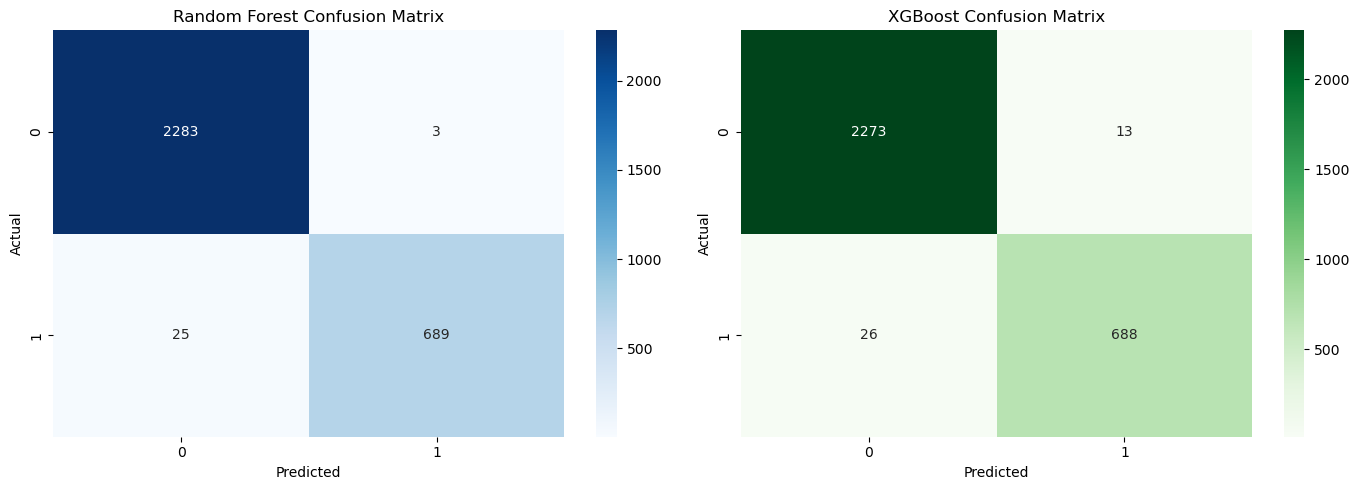

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# XGBoost confusion matrix
xgb_cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

ROC Curves
shows the trade-off between true positive rate and false positive rate.
 The area under the curve (AUC) tells me how good the model is at distinguishing between classes.

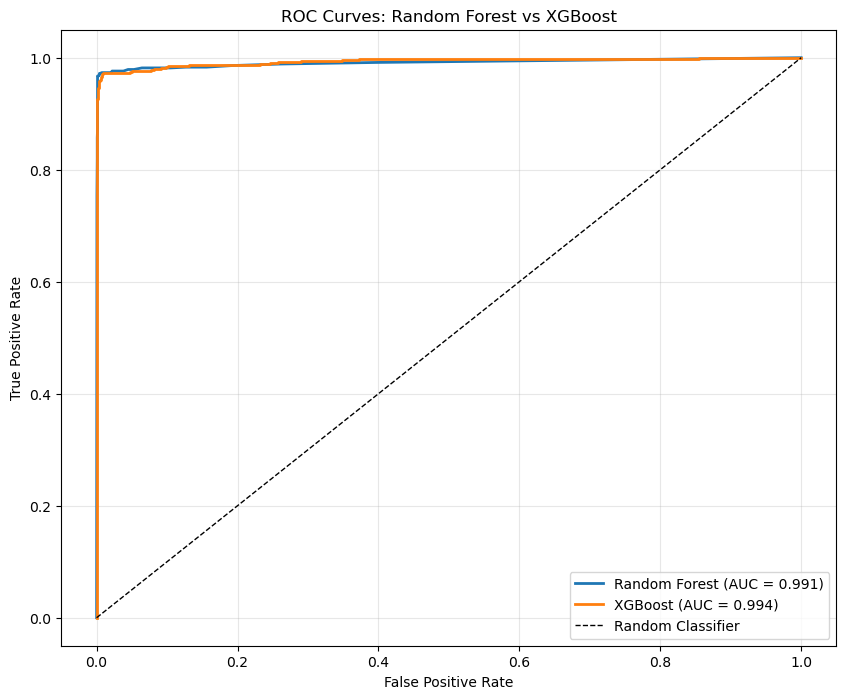

In [ ]:
# Get prediction probabilities
rf_proba = rf_model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate ROC curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

# Calculate AUC
rf_auc = roc_auc_score(y_test, rf_proba)
xgb_auc = roc_auc_score(y_test, xgb_proba)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', linewidth=2)
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Random Forest vs XGBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20704\2630228574.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance.head(10), x='importance', y='feature', ax=axes[0], palette='Blues_r')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20704\2630228574.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgb_importance.head(10), x='importance', y='feature', ax=axes[1], palette='Greens_r')


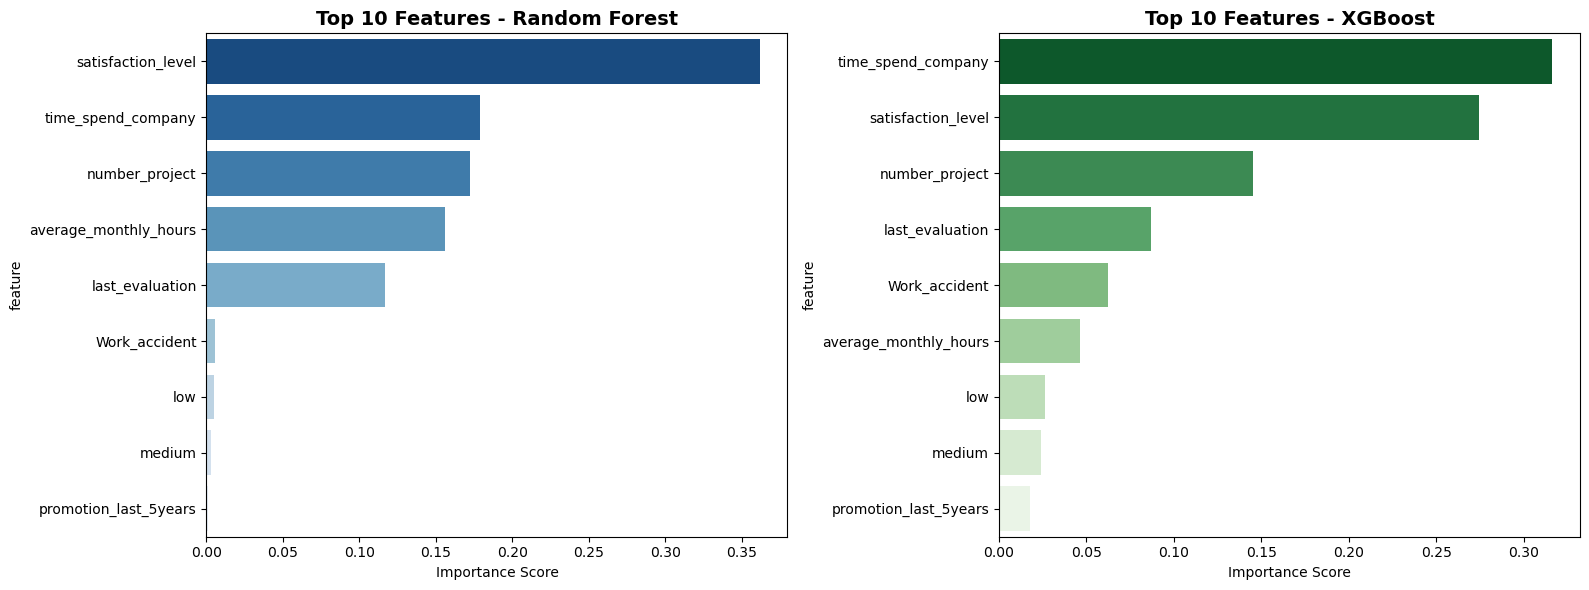


Top 5 features according to XGBoost:
              feature  importance
4  time_spend_company    0.316377
0  satisfaction_level    0.274509
2      number_project    0.145245
1     last_evaluation    0.087123
5       Work_accident    0.062267


In [ ]:
# Get feature importances from both models
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest feature importance
sns.barplot(data=rf_importance.head(10), x='importance', y='feature', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Features - Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# XGBoost feature importance
sns.barplot(data=xgb_importance.head(10), x='importance', y='feature', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Features - XGBoost', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("\nTop 5 features according to XGBoost:")
print(xgb_importance.head(5))

Choosing which model to use in production.

In [ ]:
# Create a comprehensive comparison
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC Score', 'Training Time', 'Interpretability'],
    'Random Forest': [f"{rf_accuracy:.3f}", f"{rf_auc:.3f}", 'Moderate', 'High'],
    'XGBoost': [f"{xgb_accuracy:.3f}", f"{xgb_auc:.3f}", 'Faster', 'Medium']
})

print("Model Comparison Summary:")
print(comparison)
print("\n")

# My thought process:
print("🎯 My Decision:")
if xgb_accuracy > rf_accuracy:
    print("✅ I'm leaning towards XGBoost - it's slightly more accurate and faster to train.")
    print("   The features it considers important also align well with our business understanding.")
    print("   In HR analytics, even a small improvement in accuracy can mean identifying")
    print("   several more at-risk employees correctly.")
else:
    print("✅ Random Forest is a solid choice - it's interpretable and performs well.")
    print("   Sometimes simpler is better, especially when explaining to stakeholders.")

Model Comparison Summary:
             Metric Random Forest XGBoost
0          Accuracy         0.991   0.987
1         AUC Score         0.991   0.994
2     Training Time      Moderate  Faster
3  Interpretability          High  Medium


🎯 My Decision:
✅ Random Forest is a solid choice - it's interpretable and performs well.
   Sometimes simpler is better, especially when explaining to stakeholders.


this are my views in the model selection


XGBoost wins over the Random Forest - The difference in the accuracy may be marginal, yet in the context of HR, it would imply a few additional at-risk employees being identified.

Importance of features is understandable - The level of satisfaction, the number of projects, and working hours are always on the list of the most predictive features. This is what we observed in our EDA.

It is not the ideal model - According to the confusion matrix, we are still committing some errors. Not bad - nothing is faultless, and this model is capable of offering useful information to HR departments.

Next steps - I would like to apply this model to new data in the future and how it would perform in reality. Perhaps even install a mechanism to remodel it once in a while with increased data.

The true test will be whether this model assists the HR teams to retain employees in fact. It is what counts at the bottom line after all not scores on accuracy, but actual effects in the real world!